The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



C:\Users\walkerchi\AppData\Local\Temp\ipykernel_23248\3438505530.py:32: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  selfloops.append(Arc((pos[u,0],pos[u,1]+diameter/2), diameter, diameter, 0, 0, 360, color="black", linewidth=0.5))


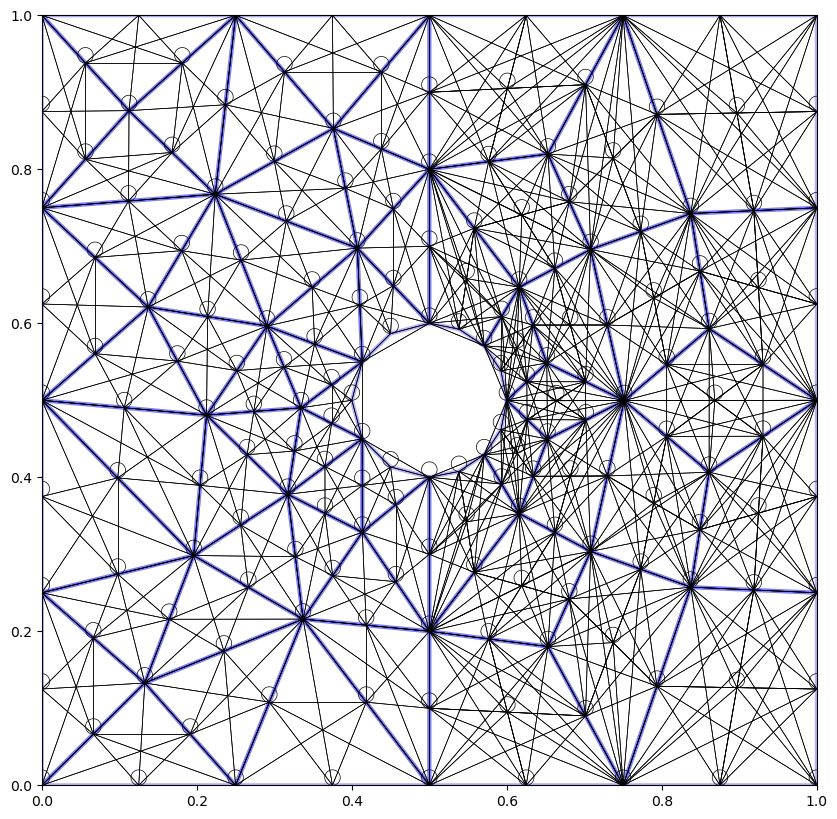

In [6]:
%load_ext autoreload
%autoreload 1
import sys 
sys.path.append("../..")
import matplotlib.pyplot as plt 
import numpy as np
from matplotlib import patches
from matplotlib.collections import PatchCollection, LineCollection
from matplotlib.patches import Polygon, Arc
%aimport tensormesh



mesh_gen = tensormesh.MeshGen(element_type=None, chara_length=0.3, order=2)
mesh_gen.add_rectangle(0,0,0.5,1, element="tri")
mesh_gen.add_rectangle(0.5,0,0.5,1, element="quad")
mesh_gen.remove_circle(0.5,0.5,0.1)
mesh = mesh_gen.gen()


adj = mesh.node_adjacency()
row, col = adj.row.numpy(), adj.col.numpy()


pos = mesh.points.numpy()
fig, ax = plt.subplots(figsize=(10,10))
lines = []
selfloops = []
diameter = 0.02
for (u, v) in zip(row, col):
    if u == v:
        selfloops.append(Arc((pos[u,0],pos[u,1]+diameter/2), diameter, diameter, 0, 0, 360, color="black", linewidth=0.5))
    else:
        line = (pos[u], pos[v])
        lines.append(line)
lc = LineCollection(lines, color="black", linewidth=0.5)
loops = PatchCollection(selfloops, match_original=True)
ax.add_collection(lc)
ax.add_collection(loops)
for value in mesh.elements().values():
    edgecolor = 'blue'
    linewidth = 3
    alpha     = 0.3
    if value.shape[1] == 3: # tri
        ax.triplot(pos[:,0], pos[:,1], value, color=edgecolor, linewidth=linewidth)
    elif value.shape[1] == 4: # quad
        polygons = [patches.Polygon(pos[element], closed=True, fill=False, edgecolor=edgecolor, alpha=alpha, linewidth=linewidth) for element in value]
        polygons = PatchCollection(polygons, match_original=True)
        ax.add_collection(polygons)
    elif value.shape[1] == 6: # tri6
        order = np.array([0, 3, 1, 4, 2, 5])
        polygons = [patches.Polygon(pos[element[order]], closed=True, fill=False, edgecolor=edgecolor, alpha=alpha,  linewidth=linewidth) for element in value]
        polygons = PatchCollection(polygons, match_original=True)
        ax.add_collection(polygons)
    elif value.shape[1] == 9: # quad9 
        order = np.array([0, 4, 1, 5, 2, 6, 3, 7])
        polygons = [patches.Polygon(pos[element[order]], closed=True, fill=False, edgecolor=edgecolor, alpha=alpha, linewidth=linewidth) for element in value]
        polygons = PatchCollection(polygons, match_original=True)
        ax.add_collection(polygons)
    else:
        raise NotImplementedError(f"element type {value.shape[1]} is not supported")
plt.show()